# Volcano Map Axes

### IMPORT ARGUMENTS

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy

from obspy import read_inventory, read_events

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cartopy.feature as cfeature

import utils

In [2]:
def inventory2stationdf(inv):
    import pandas as pd
    stations = []
    for net in inv:
        for sta in net:
            stations.append(dict({
                'name':sta.code,
                'lon':sta.longitude,
                'lat':sta.latitude,
                'used':True,
            }))
    stations = pd.DataFrame(stations)
    return stations

def obspyCat2df( eqcat ):
    for eq in eqcat:
        import pandas as pd
        eqhypos = []
        eqhypos.append(dict({
            'lat'  :eq.origins[-1].latitude,
            'lon'  :eq.origins[-1].longitude,
            'depth':eq.origins[-1].depth,
        }))
    eqhypos = pd.DataFrame(eqhypos)
    return eqhypos
            

### LOAD DATA

In [3]:
# VOLCANO
volc = dict({'lat':45.374, 'lon':-121.695, 'elev':3426}) # Mt Hood

print(volc)
print()

# CATALOG
#eqcat = pd.read_csv('./data/agung_catalog.txt', parse_dates=[3], index_col=[3]).tz_localize('UTC')#.tz_convert('Asia/Singapore')
eqcat   = read_events('./data/mthood_example1.xml')
eqhypos = obspyCat2df(eqcat)
eqhypos = eqhypos[0:]
print(eqhypos)
print('')

# SEISMOMETERS
inventory = read_inventory('./data/mthood_stationmetadata.xml')
stations = inventory2stationdf(inventory)
print(stations)

{'lat': 45.374, 'lon': -121.695, 'elev': 3426}



/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/obspy/io/quakeml/core.py:184: UserWarning: Could not convert 0.3759811
287 to type <class 'float'>. Returning None.
  warnings.warn(msg % (text, convert_to))


         lat         lon        depth
0  45.369076 -121.703209  9447.877884

    name         lon        lat  used
0   BRSP -121.708430  45.401550  True
1   HIYU -121.807396  45.435230  True
2   HTHR -121.659045  45.338775  True
3   LSON -121.647190  45.359600  True
4    MHX -121.672363  45.344186  True
5   PALM -121.705536  45.358574  True
6   SHRK -121.528770  45.464317  True
7   STAD -121.659385  45.339172  True
8   TIMB -121.710358  45.335720  True
9   YOCR -121.743539  45.379178  True
10  HOOD -121.650932  45.322262  True
11   MHD -121.702919  45.397499  True
12   TDH -121.791519  45.289669  True
13  TIMB -121.710358  45.335720  True
14   VFP -121.466270  45.317902  True
15   VHE -121.667023  45.329010  True
16   VLL -121.680351  45.463169  True


### USER SETTINGS

In [4]:
filepath = './test_eqmap'
grid_size = 0.01 # grid_size for eq heatmap in degrees
map_style = 'terrain-background'
zoom_level = 12
radial_map_extent = 10 # km
radius_km = 5 # km
transform = ccrs.PlateCarree()
#transform = ccrs.PlateCarree(central_longitude=volc['lon'])
#transform = ccrs.AlbersEqualArea(central_longitude=volc['lon'], central_latitude=volc['lat'])
#transform = ccrs.AzimuthalEquidistant(central_longitude=volc['lon'], central_latitude=volc['lat'])
#transform = ccrs.Mercator(central_longitude=volc['lon'], latitude_true_scale=volc['lat'])
#transform = ccrs.Orthographic(volc['lon'], volc['lat'])

### CREATE MAP

Saving .png
Saving .svg


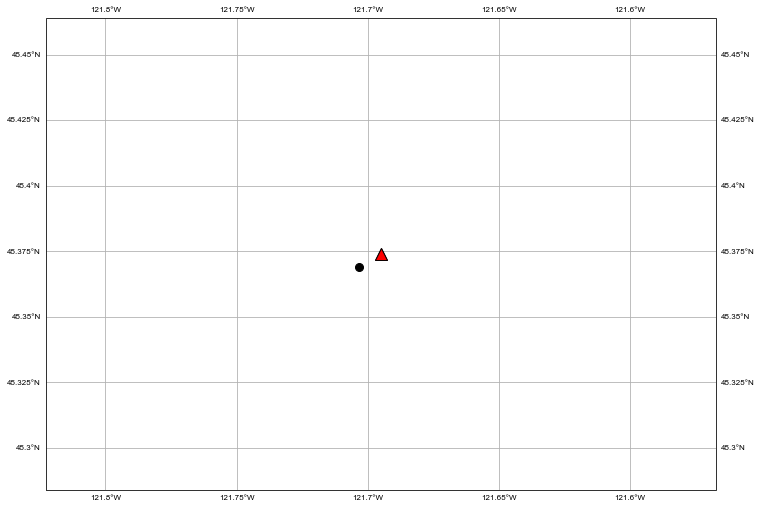

In [6]:
plt.style.use('./utils/eqmap.mplstyle')
fig = plt.figure() # default figsize is [12x12]
axm = fig.add_subplot(1, 1, 1, projection=transform)
axm = utils.set_radial_map_extent(axm, volc['lat'], volc['lon'], radial_map_extent, crs=transform) # Limit the extent of the map to a small longitude/latitude range.
axm = utils.set_radial_map_extent(axm, volc['lat'], volc['lon'], radial_map_extent, crs=ccrs.Geodetic()) # Limit the extent of the map to a small longitude/latitude range.

#axm = utils.stamen_background(axm, map_style, zoom_level)                              # add background image
#axm = utils.plot_heatmap(axm, eqcat, grid_size, colormap='magma_r')                    # plot EQ heatmap
#axm = utils.plot_hypo(axm, eqhypos['lat'][0], eqhypos['lon'][0], transform=transform)   # plot EQ hypocenter
axm = utils.plot_hypo(axm, eqhypos['lat'][0], eqhypos['lon'][0], transform=ccrs.Geodetic())   # plot EQ hypocenter
axm = utils.plot_volcano(axm, volc['lat'], volc['lon'], transform=transform)           # add marker for volcano
axm = utils.plot_volcano(axm, volc['lat'], volc['lon'], transform=ccrs.Geodetic())           # add marker for volcano
#axm = utils.plot_radius2(axm, volc['lat'], volc['lon'], radius_km, transform=transform) # add radius around point
#axm = utils.plot_station(axm, stations['lat'], stations['lon'], color='white', transform=transform) # add marker for volcano
#fig = utils.location_map(fig, volc['lat'], volc['lon'], location='top_left')
axm.gridlines(draw_labels=True)
#axm.plot(-121.708430,45.401550,'vw', markeredgecolor='k', transform=transform)
#axm.plot(-121.7,45.34,'vw', markeredgecolor='k', transform=transform)

utils.save(fig, filepath)
plt.show()

In [7]:
!jupyter nbconvert --to script config_template.ipynb

[NbConvertApp] WARNING | pattern 'config_template.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute